In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('solarpowergeneration.csv')
df

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069
...,...,...,...,...,...,...,...,...,...,...
2915,0.166453,63,27,13.9,4,10.0,75,10.0,29.93,6995
2916,0.064020,63,27,13.9,1,10.0,66,15.0,29.91,29490
2917,0.294494,63,27,13.9,2,10.0,68,21.0,29.88,17257
2918,0.524968,63,27,13.9,2,10.0,81,17.0,29.87,677


In [ ]:
print(df.shape)


(2920, 10)


In [ ]:
print(df.head)

<bound method NDFrame.head of       distance-to-solar-noon  temperature  wind-direction  wind-speed  \
0                   0.859897           69              28         7.5   
1                   0.628535           69              28         7.5   
2                   0.397172           69              28         7.5   
3                   0.165810           69              28         7.5   
4                   0.065553           69              28         7.5   
...                      ...          ...             ...         ...   
2915                0.166453           63              27        13.9   
2916                0.064020           63              27        13.9   
2917                0.294494           63              27        13.9   
2918                0.524968           63              27        13.9   
2919                0.755442           63              27        13.9   

      sky-cover  visibility  humidity  average-wind-speed-(period)  \
0             0        

In [ ]:
print(df.dtypes)


distance-to-solar-noon         float64
temperature                      int64
wind-direction                   int64
wind-speed                     float64
sky-cover                        int64
visibility                     float64
humidity                         int64
average-wind-speed-(period)    float64
average-pressure-(period)      float64
power-generated                  int64
dtype: object


In [ ]:
df.isnull().sum()

,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),1
average-pressure-(period),0
power-generated,0


#Data Cleaning

In [ ]:
df.columns = [c.strip() for c in df.columns]
orig_columns = df.columns.tolist()
print("Columns:", orig_columns)


print("Column summary (non-null counts):")
display(df.info())


for col in df.columns:

    if df[col].dtype == object:

        df[col] = df[col].astype(str).str.replace(',', '')
        df[col] = df[col].replace(['', 'NA', 'N/A', 'na', '?', 'nan', 'None', 'none'], np.nan)

        try:
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass

print("After conversion attempt, dtypes:")
display(df.dtypes)


Columns: ['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed', 'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)', 'average-pressure-(period)', 'power-generated']
Column summary (non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated

None

After conversion attempt, dtypes:


,0
distance-to-solar-noon,float64
temperature,int64
wind-direction,int64
wind-speed,float64
sky-cover,int64
visibility,float64
humidity,int64
average-wind-speed-(period),float64
average-pressure-(period),float64
power-generated,int64


#Missing Values

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Non-numeric columns:", non_numeric_cols)


missing_pct = (df.isna().sum() / len(df) * 100).round(2)
display(pd.DataFrame({'missing_count': df.isna().sum(), 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False))

df_raw = df.copy()
for col in numeric_cols:
    if df[col].isna().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed numeric column '{col}' with median {median_val:.4f}")

for col in non_numeric_cols:
    if df[col].isna().any():
        try:
            mode_val = df[col].mode().iloc[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Imputed non-numeric column '{col}' with mode '{mode_val}'")
        except Exception:
            df[col].fillna("Unknown", inplace=True)
            print(f"Filled non-numeric column '{col}' with 'Unknown'")

,0
average-wind-speed-(period),1


Numeric columns: ['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed', 'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)', 'average-pressure-(period)', 'power-generated']
Non-numeric columns: []


,missing_count,missing_pct
average-wind-speed-(period),1,0.03
distance-to-solar-noon,0,0.00
temperature,0,0.00
wind-direction,0,0.00
sky-cover,0,0.00
wind-speed,0,0.00
visibility,0,0.00
humidity,0,0.00
average-pressure-(period),0,0.00
power-generated,0,0.00


Imputed numeric column 'average-wind-speed-(period)' with median 9.0000


Now, create a new Python file named `app.py` in your local environment with the following content. This file will be your Streamlit application.

```python
import streamlit as st
import pandas as pd
import joblib
import numpy as np

@st.cache_resource
def load_model_and_scaler():
    model = joblib.load('xgboost_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

model, scaler = load_model_and_scaler()

st.title('Solar Power Generation Prediction')
st.write('Enter the environmental conditions to predict solar power generation.')


distance_to_solar_noon = st.slider('Distance to Solar Noon', 0.0, 1.0, 0.5)
temperature = st.slider('Temperature (Fahrenheit)', 0, 100, 70)
wind_direction = st.slider('Wind Direction (Degrees)', 0, 360, 180)
wind_speed = st.slider('Wind Speed (mph)', 0.0, 50.0, 10.0)
sky_cover = st.slider('Sky Cover (0-8)', 0, 8, 4)
visibility = st.slider('Visibility (miles)', 0.0, 10.0, 10.0)
humidity = st.slider('Humidity (%)', 0, 100, 50)
average_wind_speed_period = st.slider('Average Wind Speed (period) (mph)', 0.0, 50.0, 10.0)
average_pressure_period = st.slider('Average Pressure (period) (inches Hg)', 29.0, 31.0, 29.9)

# Create a DataFrame from inputs
input_data = pd.DataFrame([{
    'distance-to-solar-noon': distance_to_solar_noon,
    'temperature': temperature,
    'wind-direction': wind_direction,
    'wind-speed': wind_speed,
    'sky-cover': sky_cover,
    'visibility': visibility,
    'humidity': humidity,
    'average-wind-speed-(period)': average_wind_speed_period,
    'average-pressure-(period)': average_pressure_period
}])

scaled_input_data = scaler.transform(input_data)

if st.button('Predict Power Generation'):
    prediction = model.predict(scaled_input_data)[0]
    st.success(f'Predicted Power Generated: {prediction:.2f} units')

```

**To run this Streamlit application:**

1.  **Download the saved files:** After running the code above, download `xgboost_model.pkl` and `scaler.pkl` from your Colab environment to the same directory where you will save `app.py`.
2.  **Save the `app.py` file:** Create a file named `app.py` in a local directory and paste the Streamlit code into it.
3.  **Install Streamlit:** If you haven't already, install Streamlit: `pip install streamlit`
4.  **Run the app:** Open your terminal or command prompt, navigate to the directory where you saved `app.py`, and run: `streamlit run app.py`

This will open the Streamlit application in your web browser, allowing you to interact with your deployed XGBoost model!

In [ ]:
df.isnull().sum()


,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),0
average-pressure-(period),0
power-generated,0


#Statistical Summary

In [ ]:
numeric_summary = df[numeric_cols].describe().T
numeric_summary['median'] = df[numeric_cols].median().round(4)
numeric_summary['IQR'] = (df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)).round(4)
numeric_summary['skew'] = df[numeric_cols].skew().round(4)
numeric_summary['kurtosis'] = df[numeric_cols].kurtosis().round(4)
display(numeric_summary[['count','mean','median','std','min','25%','50%','75%','max','IQR','skew','kurtosis']])

skewed = numeric_summary[numeric_summary['skew'].abs() > 1]
print("Columns with |skew| > 1 (potentially skewed distributions):")
display(skewed[['mean','median','std','IQR','skew']])

,count,mean,median,std,min,25%,50%,75%,max,IQR,skew,kurtosis
distance-to-solar-noon,2920.0,0.503294,0.479,0.298024,0.050401,0.243714,0.478957,0.739528,1.141361,0.4958,0.2115,-0.9873
temperature,2920.0,58.468493,59.000,6.841200,42.000000,53.000000,59.000000,63.000000,78.000000,10.0000,0.1259,-0.2874
wind-direction,2920.0,24.953425,27.000,6.915178,1.000000,25.000000,27.000000,29.000000,36.000000,4.0000,-1.6295,1.8566
wind-speed,2920.0,10.096986,10.000,4.838185,1.100000,6.600000,10.000000,13.100000,26.600000,6.5000,0.4169,0.0786
sky-cover,2920.0,1.987671,2.000,1.411978,0.000000,1.000000,2.000000,3.000000,4.000000,2.0000,0.0803,-1.3415
visibility,2920.0,9.557705,10.000,1.383884,0.000000,10.000000,10.000000,10.000000,10.000000,0.0000,-3.8624,15.7185
humidity,2920.0,73.513699,77.000,15.077139,14.000000,65.000000,77.000000,84.000000,100.000000,19.0000,-0.9556,0.8722
average-wind-speed-(period),2920.0,10.128767,9.000,7.260333,0.000000,5.000000,9.000000,15.000000,40.000000,10.0000,0.6232,0.0165
average-pressure-(period),2920.0,30.017760,30.000,0.142006,29.480000,29.920000,30.000000,30.110000,30.530000,0.1900,0.4414,0.3523
power-generated,2920.0,6979.846233,404.000,10312.336413,0.000000,0.000000,404.000000,12723.500000,36580.000000,12723.5000,1.3070,0.3422


Columns with |skew| > 1 (potentially skewed distributions):


,mean,median,std,IQR,skew
wind-direction,24.953425,27.0,6.915178,4.0,-1.6295
visibility,9.557705,10.0,1.383884,0.0,-3.8624
power-generated,6979.846233,404.0,10312.336413,12723.5,1.3070


#Outlier Detection and Treatment

In [ ]:
def iqr_outliers_series(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (s < lower) | (s > upper), lower, upper

outlier_report = []
for col in numeric_cols:
    flags, lo, hi = iqr_outliers_series(df[col])
    n_out = flags.sum()
    pct = n_out / len(df) * 100
    outlier_report.append((col, n_out, round(pct,2), lo, hi))
outlier_df = pd.DataFrame(outlier_report, columns=['feature','n_outliers','pct_outliers','lower_bound','upper_bound']).sort_values('pct_outliers', ascending=False)
print("Potential outlier counts (IQR method):")
display(outlier_df)

from scipy.stats.mstats import winsorize
df_winsor = df.copy()
for col in numeric_cols:

    lower_perc = df[col].quantile(0.01)
    upper_perc = df[col].quantile(0.99)
    df_winsor[col] = df[col].clip(lower=lower_perc, upper=upper_perc)

Potential outlier counts (IQR method):


,feature,n_outliers,pct_outliers,lower_bound,upper_bound
2,wind-direction,528,18.08,19.000000,35.000000
5,visibility,429,14.69,10.000000,10.000000
9,power-generated,107,3.66,-19085.250000,31808.750000
6,humidity,83,2.84,36.500000,112.500000
3,wind-speed,40,1.37,-3.150000,22.850000
8,average-pressure-(period),31,1.06,29.635000,30.395000
7,average-wind-speed-(period),25,0.86,-10.000000,30.000000
0,distance-to-solar-noon,0,0.00,-0.500006,1.483248
1,temperature,0,0.00,38.000000,78.000000
4,sky-cover,0,0.00,-2.000000,6.000000


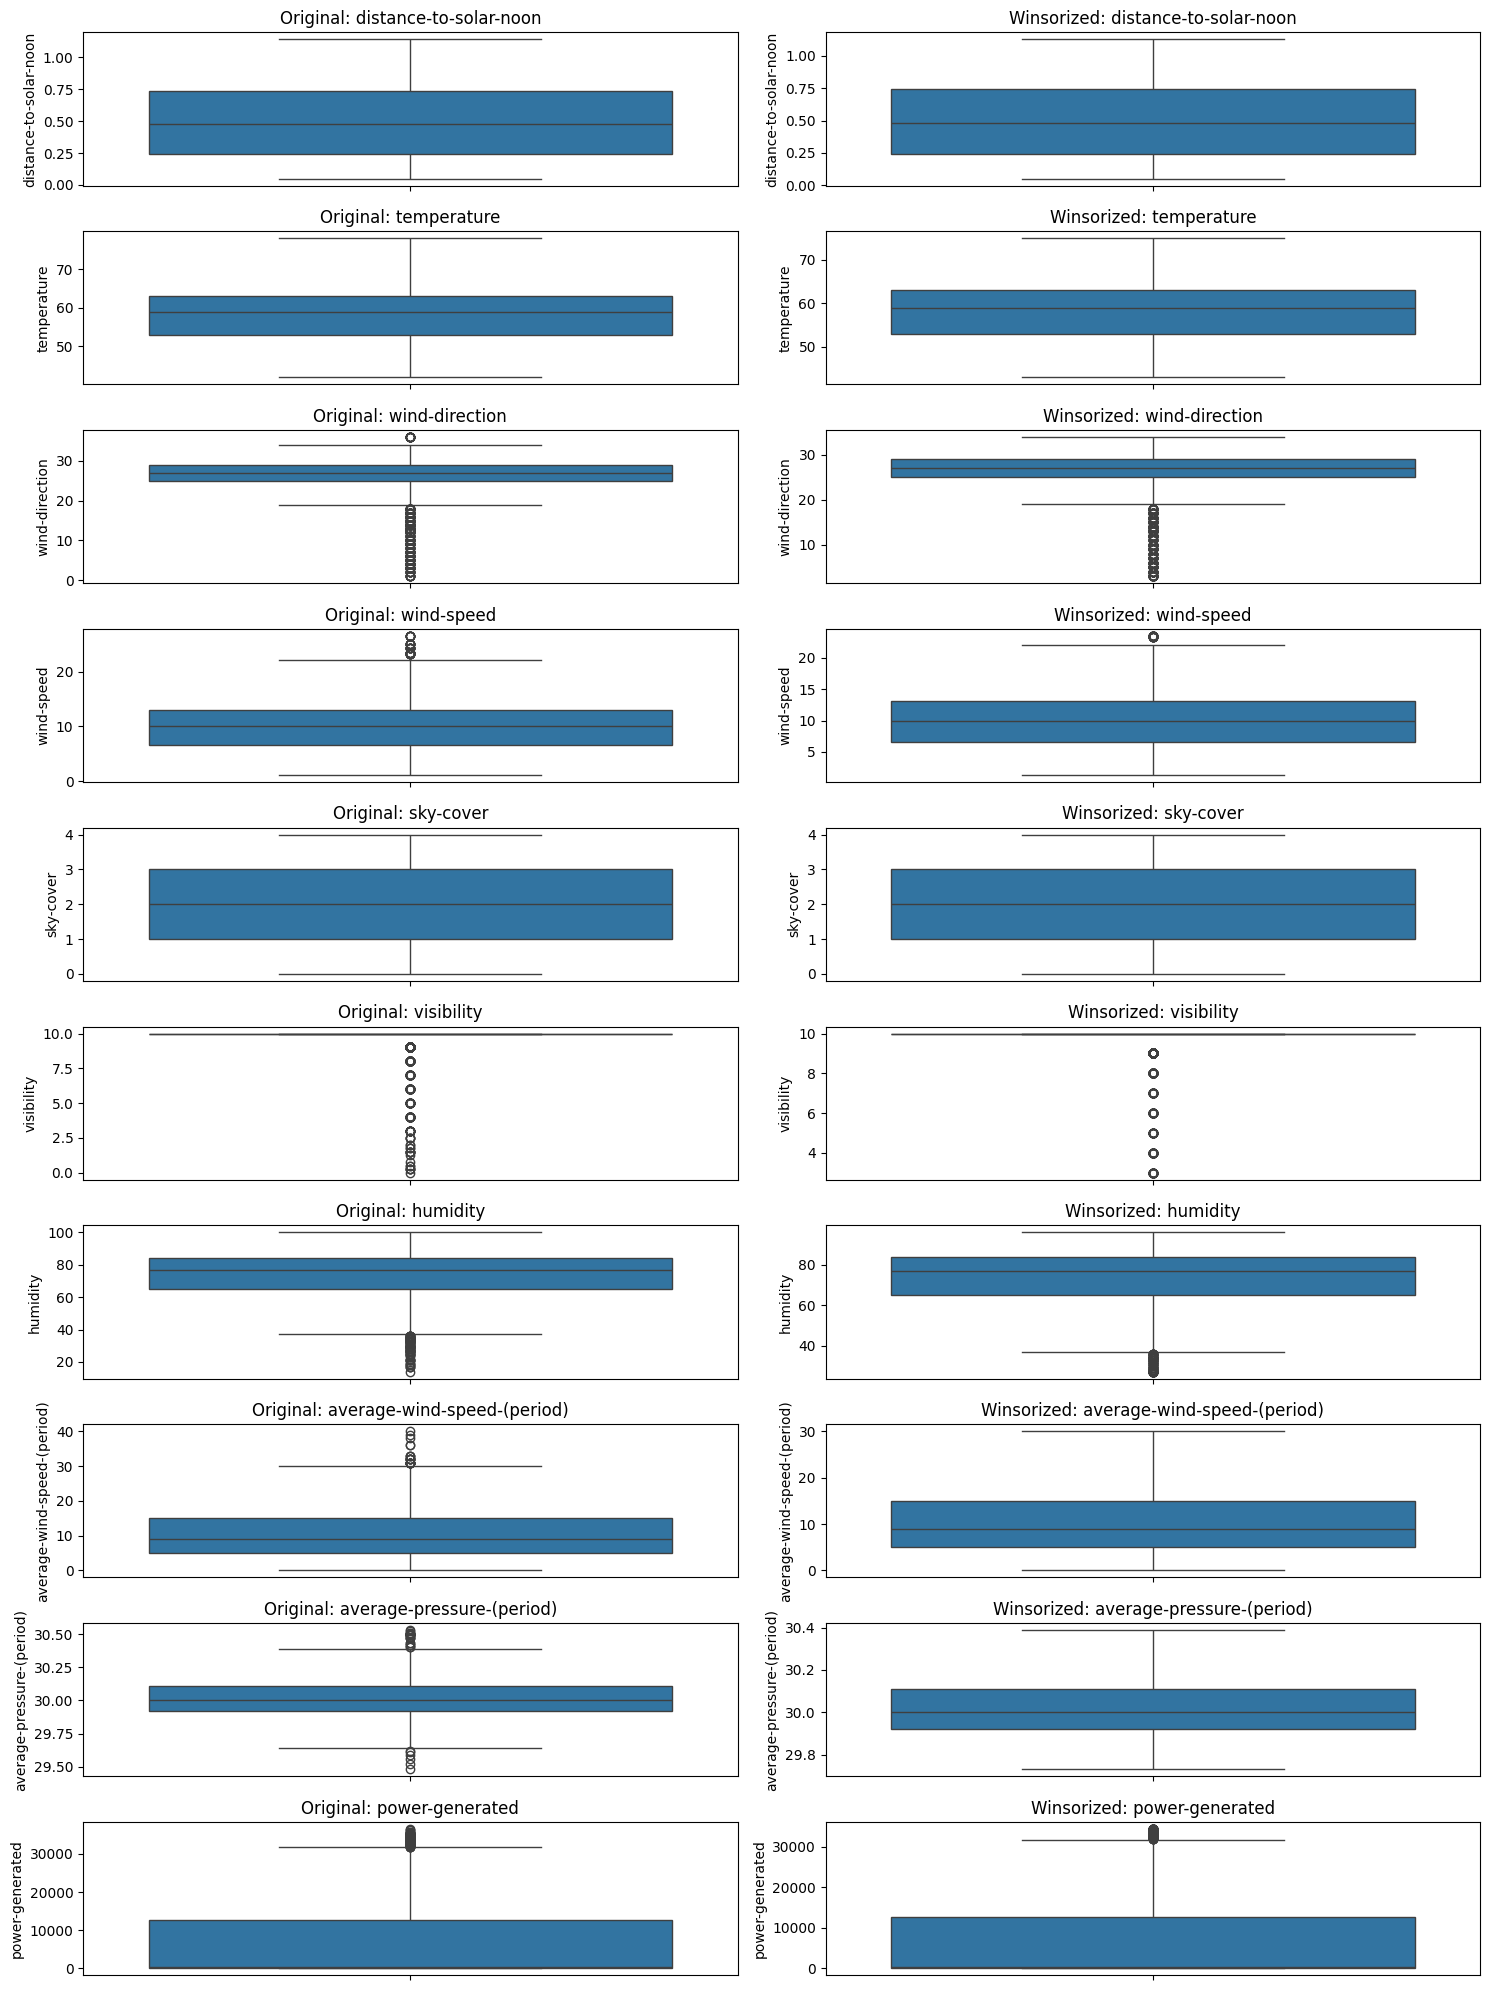

In [ ]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 2, 2*i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Original: {col}')

    plt.subplot(len(numeric_cols), 2, 2*i + 2)
    sns.boxplot(y=df_winsor[col])
    plt.title(f'Winsorized: {col}')
plt.tight_layout()
plt.show()

#Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df_winsor.drop('power-generated', axis=1)
y = df_winsor['power-generated']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2336, 9)
Shape of X_test: (584, 9)
Shape of y_train: (2336,)
Shape of y_test: (584,)


In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled training features (first 5 rows):")
display(X_train_scaled.head())
print("Scaled testing features (first 5 rows):")
display(X_test_scaled.head())

Scaled training features (first 5 rows):


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period)
2651,-1.143794,0.974870,0.307106,0.743962,-0.722258,0.33911,-0.391774,0.537368,-1.002091
1709,-0.682531,-0.645562,0.307106,2.826434,-0.014245,0.33911,-0.663762,2.758630,-0.929798
869,0.028089,-1.676746,-0.703926,-0.286756,1.401780,0.33911,-0.323777,0.120881,0.877532
2355,-1.181097,1.269494,0.595972,0.133945,-1.430270,0.33911,-0.255780,-0.712092,-1.363557
2915,-1.122270,0.680246,0.307106,0.807068,1.401780,0.33911,0.084205,-0.017948,-0.640625


Scaled testing features (first 5 rows):


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period)
2437,-0.823774,0.827558,0.595972,0.470507,-0.722258,0.33911,-1.003748,1.509170,-1.146678
2470,-0.144149,0.532934,0.307106,1.206734,-0.722258,0.33911,-0.119786,1.092683,-0.351453
2359,0.533624,1.269494,0.595972,0.133945,-1.430270,0.33911,-0.119786,0.398539,-1.941903
789,0.042189,-1.234810,1.173704,-1.086088,-0.014245,0.33911,-0.187783,-1.406237,0.371479
1642,-0.256983,-0.498250,0.307106,1.269839,-0.722258,0.33911,0.832173,-0.712092,1.022118


## Data Visualization for EDA

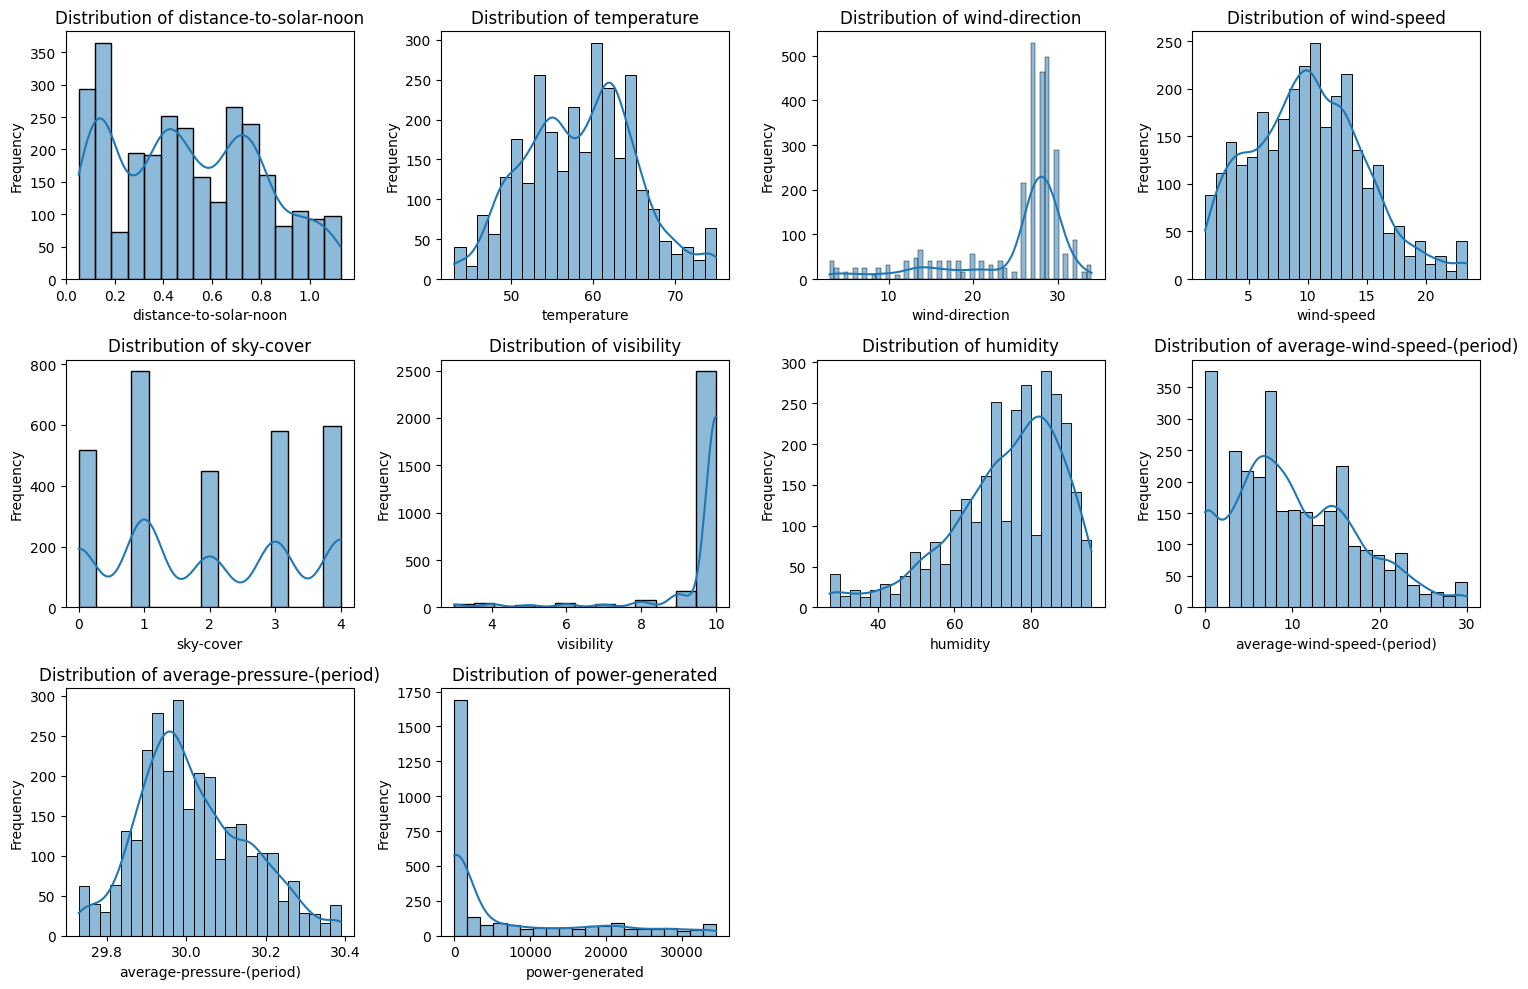

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df_winsor[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

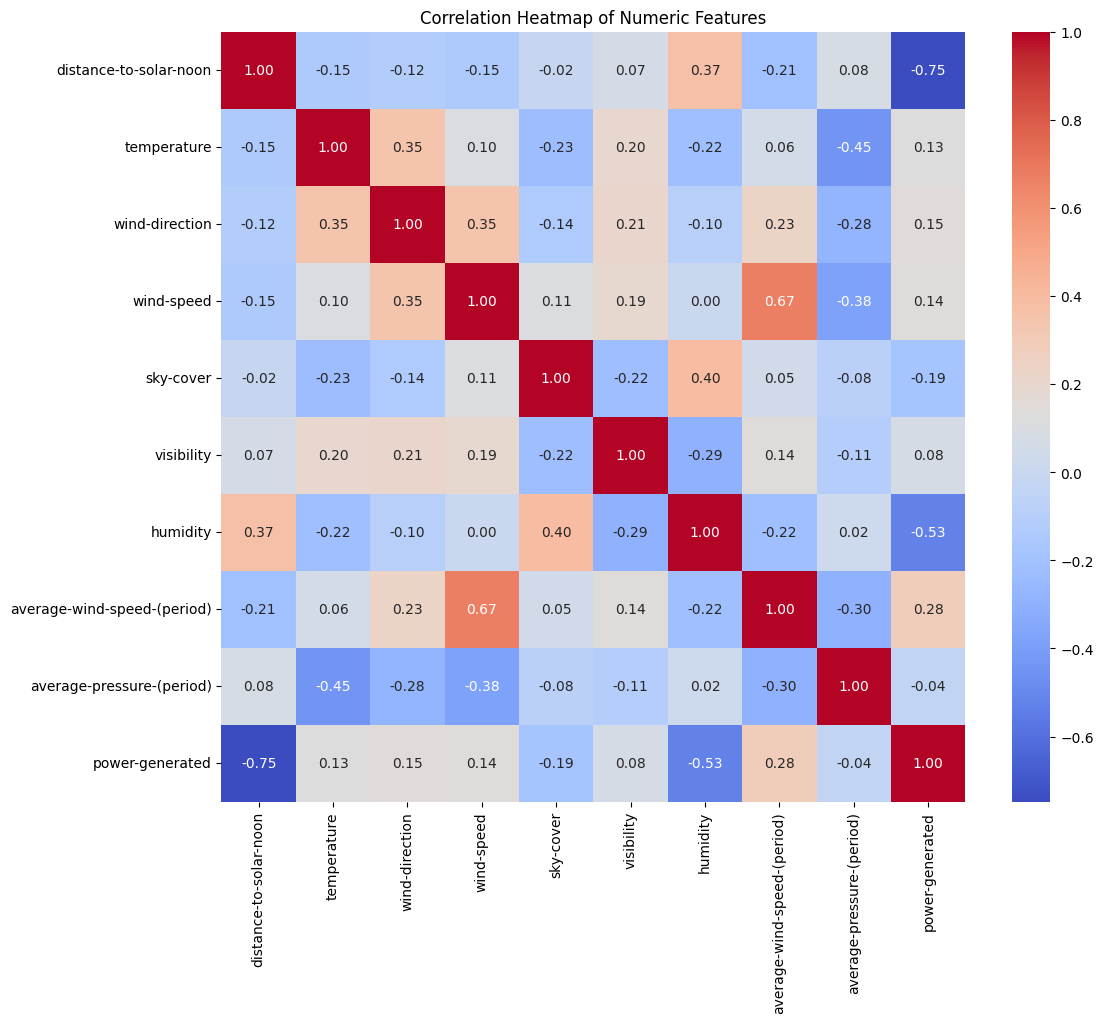

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_winsor.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

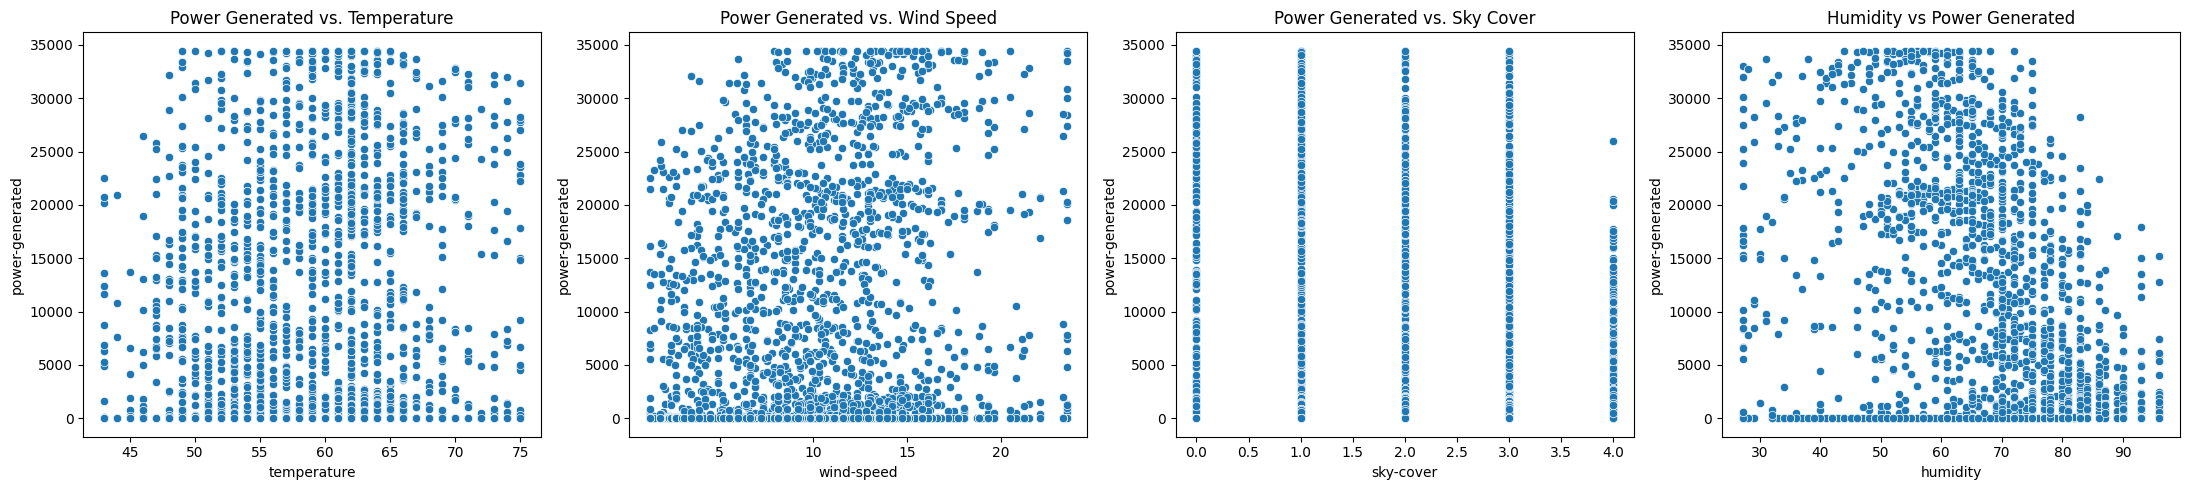

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5)) # Changed to 4 subplots
sns.scatterplot(x='temperature', y='power-generated', data=df_winsor, ax=axes[0])
axes[0].set_title('Power Generated vs. Temperature')

sns.scatterplot(x='wind-speed', y='power-generated', data=df_winsor, ax=axes[1])
axes[1].set_title('Power Generated vs. Wind Speed')

sns.scatterplot(x='sky-cover', y='power-generated', data=df_winsor, ax=axes[2])
axes[2].set_title('Power Generated vs. Sky Cover')

sns.scatterplot(x="humidity", y="power-generated", data=df_winsor, ax=axes[3])
axes[3].set_title("Humidity vs Power Generated") # Corrected set_title method

plt.tight_layout()
plt.show()

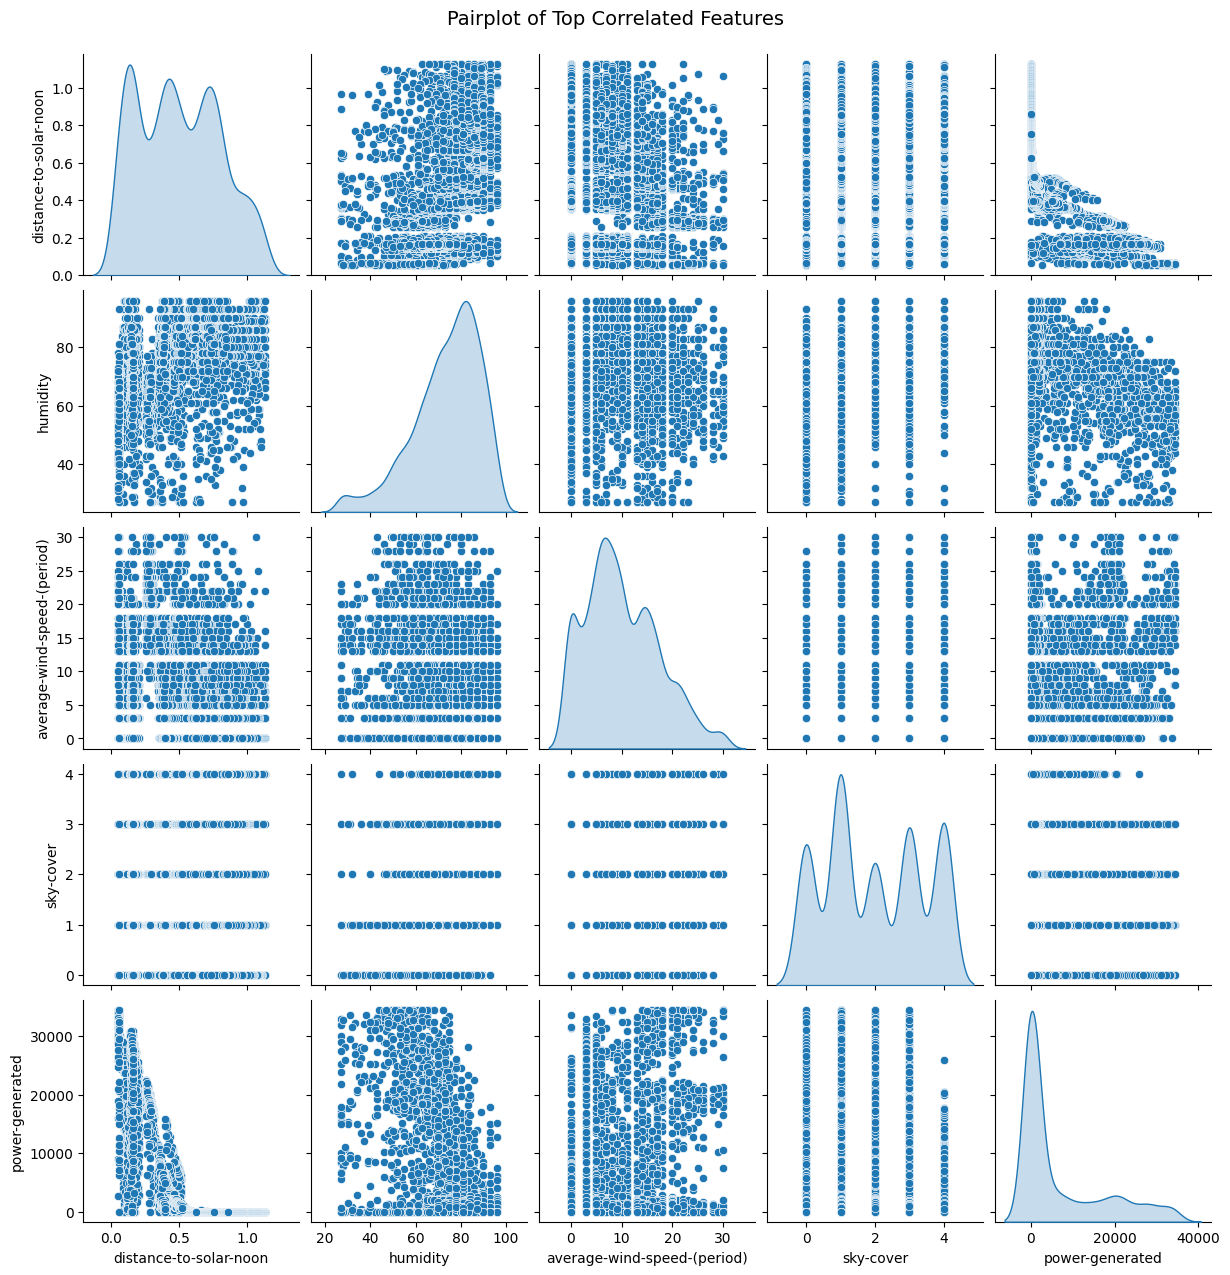

In [ ]:
top_corr = (
    df_winsor.corr(numeric_only=True)["power-generated"]
    .abs()
    .sort_values(ascending=False)[1:5]
    .index
)
sns.pairplot(df_winsor, vars=list(top_corr) + ["power-generated"], diag_kind="kde") # Changed 'data' to 'df_winsor'
plt.suptitle("Pairplot of Top Correlated Features", y=1.02, fontsize=14)
plt.show()

#Model Fitting



#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression → RMSE:", rmse_lr, " R2:", r2_lr)



Linear Regression → RMSE: 6262.246086702984  R2: 0.6256354545315538


#Lasso Regression


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

pred_lasso = lasso.predict(X_test_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

print("Lasso Regression → RMSE:", rmse_lasso, " R2:", r2_lasso)



Lasso Regression → RMSE: 6262.246041920442  R2: 0.6256354598858613


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest → RMSE:", rmse_rf, " R2:", r2_rf)


Random Forest → RMSE: 3359.700330916839  R2: 0.8922454702412231


In [ ]:
#Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, pred_gbr))
r2_gbr = r2_score(y_test, pred_gbr)

print("Gradient Boosting → RMSE:", rmse_gbr, " R2:", r2_gbr)


Gradient Boosting → RMSE: 3168.8607082804156  R2: 0.9041392658155031


#XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(objective="reg:squarederror", n_estimators=300)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost → RMSE:", rmse_xgb, " R2:", r2_xgb)


XGBoost → RMSE: 3168.112931756519  R2: 0.9041845022304197


In [ ]:
import joblib

joblib.dump(xgb, 'xgboost_model.pkl')
print("XGBoost model saved as 'xgboost_model.pkl'")

joblib.dump(scaler, 'scaler.pkl')
print("StandardScaler saved as 'scaler.pkl'")

XGBoost model saved as 'xgboost_model.pkl'
StandardScaler saved as 'scaler.pkl'


#Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, pred_gbr))
r2_gbr = r2_score(y_test, pred_gbr)

print("Gradient Boosting → RMSE:", rmse_gbr, " R2:", r2_gbr)

Gradient Boosting → RMSE: 3171.2205656725714  R2: 0.9039964372626534


#Evaluation and Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

k_folds = 5

In [ ]:
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# XGBoost
r2_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=kf, scoring='r2')
mse_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_xgb = np.sqrt(-mse_scores_xgb)

print(f"XGBoost - Mean R2: {np.mean(r2_scores_xgb):.4f}, Std R2: {np.std(r2_scores_xgb):.4f}")
print(f"XGBoost - Mean RMSE: {np.mean(rmse_scores_xgb):.4f}, Std RMSE: {np.std(rmse_scores_xgb):.4f}")

XGBoost - Mean R2: 0.9040, Std R2: 0.0144
XGBoost - Mean RMSE: 3182.1065, Std RMSE: 240.7237


In [ ]:
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Lasso Regression
r2_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=kf, scoring='r2')
mse_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_lasso = np.sqrt(-mse_scores_lasso)

print(f"Lasso Regression - Mean R2: {np.mean(r2_scores_lasso):.4f}, Std R2: {np.std(r2_scores_lasso):.4f}")
print(f"Lasso Regression - Mean RMSE: {np.mean(rmse_scores_lasso):.4f}, Std RMSE: {np.std(rmse_scores_lasso):.4f}")

Lasso Regression - Mean R2: 0.6522, Std R2: 0.0264
Lasso Regression - Mean RMSE: 6065.8823, Std RMSE: 179.3137


In [ ]:
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Linear Regression
r2_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring='r2')
mse_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_lr = np.sqrt(-mse_scores_lr)

print(f"Linear Regression - Mean R2: {np.mean(r2_scores_lr):.4f}, Std R2: {np.std(r2_scores_lr):.4f}")
print(f"Linear Regression - Mean RMSE: {np.mean(rmse_scores_lr):.4f}, Std RMSE: {np.std(rmse_scores_lr):.4f}")

Linear Regression - Mean R2: 0.6522, Std R2: 0.0264
Linear Regression - Mean RMSE: 6065.8824, Std RMSE: 179.3138


In [ ]:
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Gradient Boosting
r2_scores_gbr = cross_val_score(gbr, X_train, y_train, cv=kf, scoring='r2')
mse_scores_gbr = cross_val_score(gbr, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_gbr = np.sqrt(-mse_scores_gbr)

print(f"Gradient Boosting - Mean R2: {np.mean(r2_scores_gbr):.4f}, Std R2: {np.std(r2_scores_gbr):.4f}")
print(f"Gradient Boosting - Mean RMSE: {np.mean(rmse_scores_gbr):.4f}, Std RMSE: {np.std(rmse_scores_gbr):.4f}")

Gradient Boosting - Mean R2: 0.9116, Std R2: 0.0199
Gradient Boosting - Mean RMSE: 3051.5043, Std RMSE: 307.7288


In [ ]:
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Random Forest
r2_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')
mse_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_rf = np.sqrt(-mse_scores_rf)

print(f"Random Forest - Mean R2: {np.mean(r2_scores_rf):.4f}, Std R2: {np.std(r2_scores_rf):.4f}")
print(f"Random Forest - Mean RMSE: {np.mean(rmse_scores_rf):.4f}, Std RMSE: {np.std(rmse_scores_rf):.4f}")

Random Forest - Mean R2: 0.9098, Std R2: 0.0181
Random Forest - Mean RMSE: 3072.5530, Std RMSE: 271.8059


#Visualize Predictions vs. Actuals


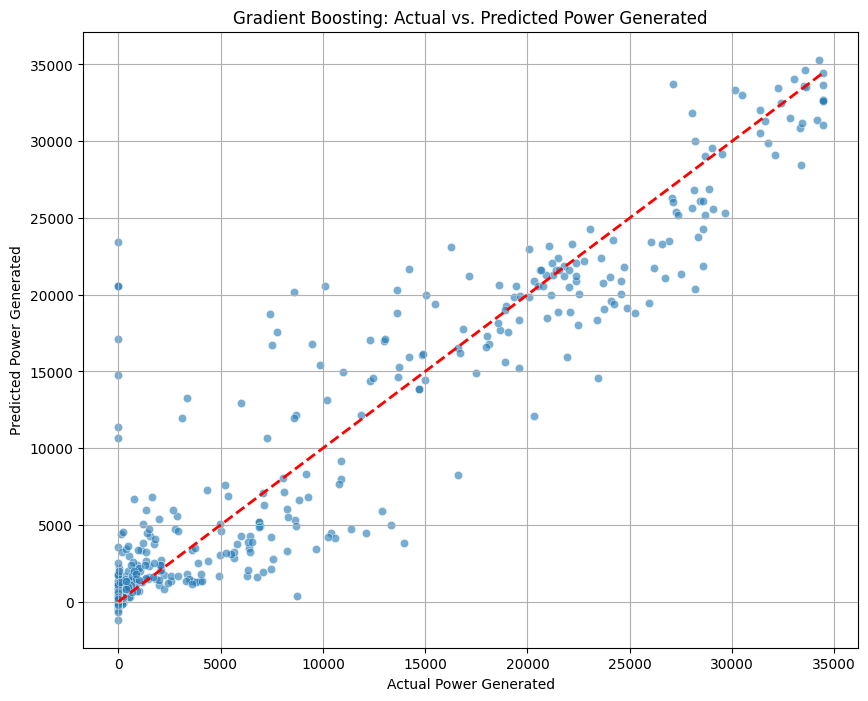

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=pred_gbr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Gradient Boosting: Actual vs. Predicted Power Generated')
plt.xlabel('Actual Power Generated')
plt.ylabel('Predicted Power Generated')
plt.grid(True)
plt.show()

In [ ]:
residuals_gbr = y_test - pred_gbr

print("Calculated residuals for Gradient Boosting.")

Calculated residuals for Gradient Boosting.


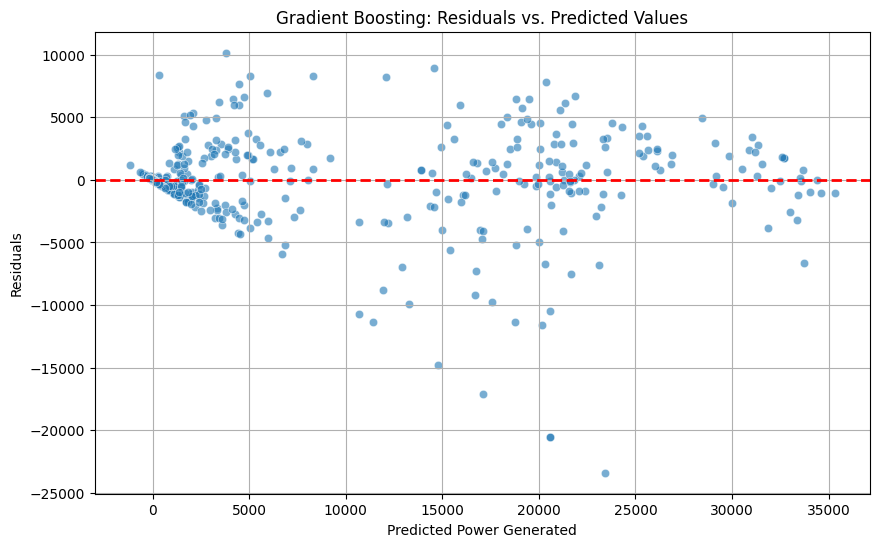

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pred_gbr, y=residuals_gbr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Gradient Boosting: Residuals vs. Predicted Values')
plt.xlabel('Predicted Power Generated')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

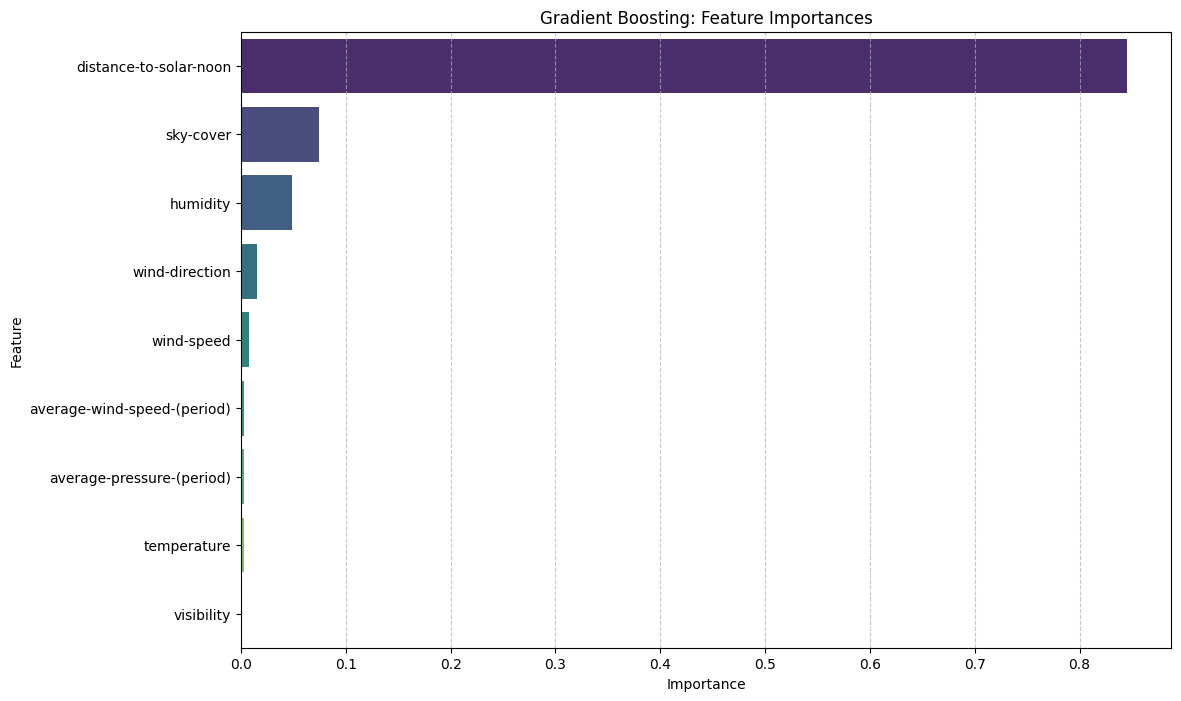

In [ ]:
feature_importances = pd.Series(gbr.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Gradient Boosting: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


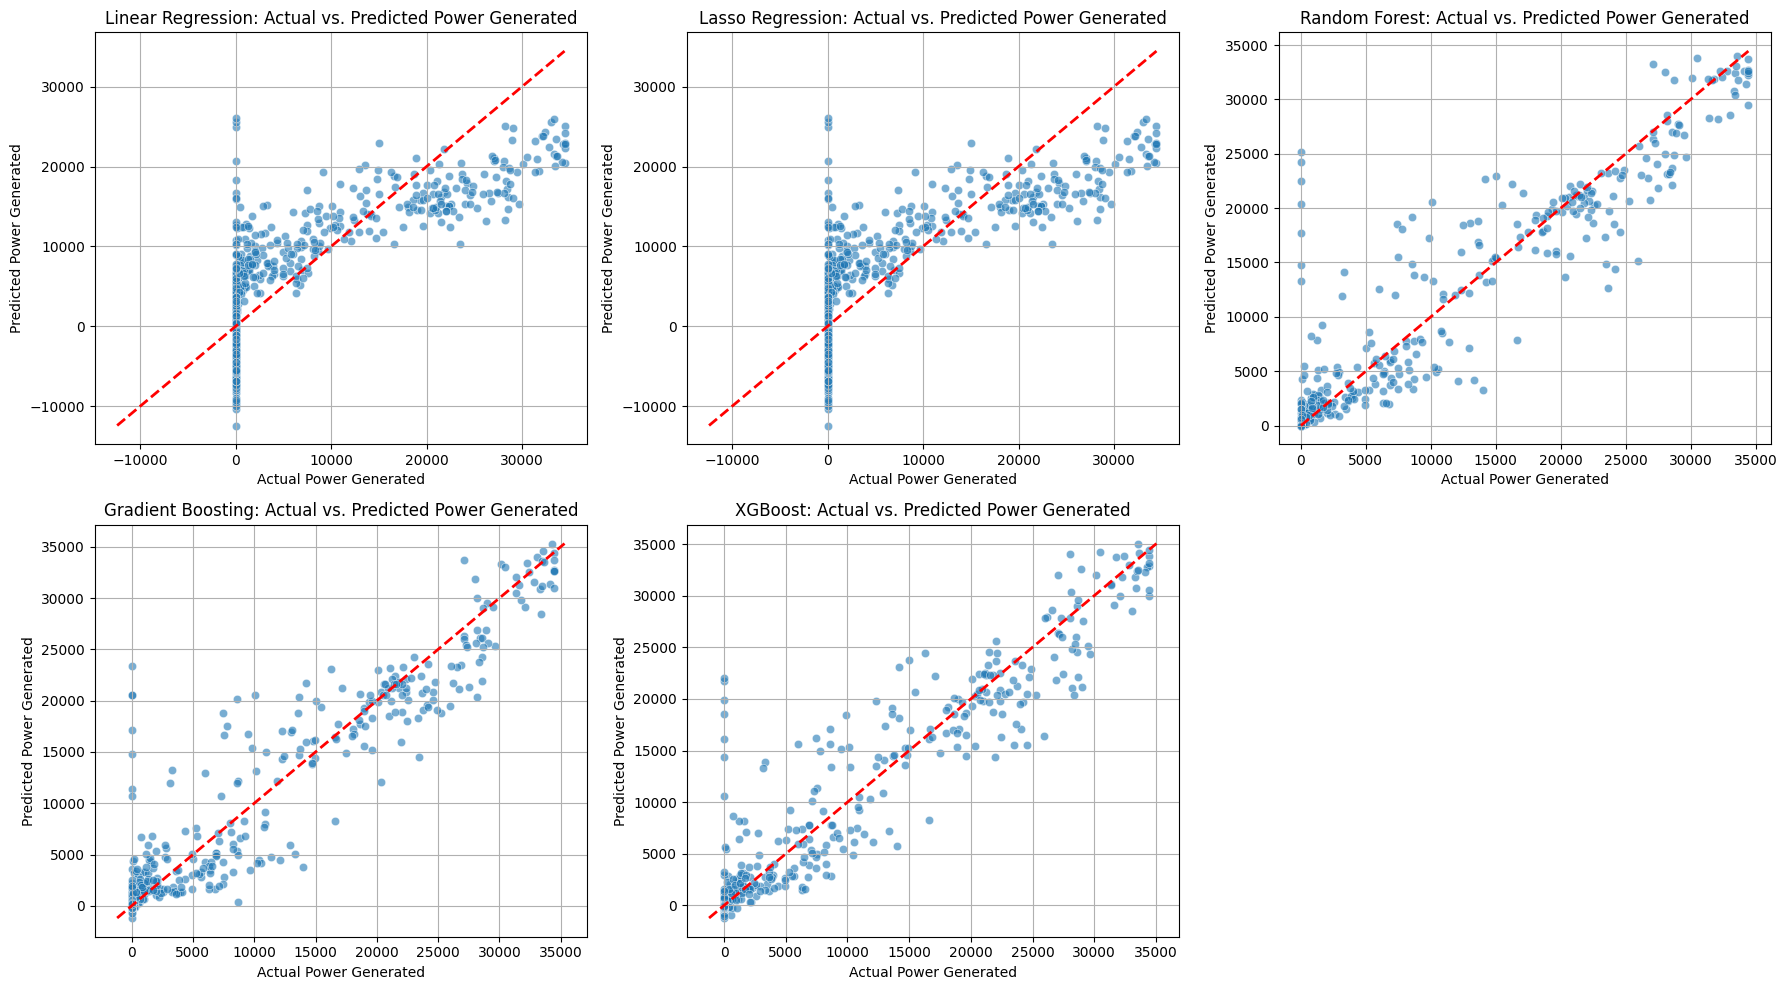

In [ ]:
models = {
    "Linear Regression": pred_lr,
    "Lasso Regression": pred_lasso,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gbr,
    "XGBoost": pred_xgb
}

num_models = len(models)
num_cols = 3 # Number of columns for subplots
num_rows = (num_models + num_cols - 1) // num_cols # Calculate number of rows needed

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, (model_name, predictions) in enumerate(models.items()):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=y_test, y=predictions, alpha=0.6)

    # Determine min and max for the diagonal line, considering both actual and predicted values
    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.title(f'{model_name}: Actual vs. Predicted Power Generated')
    plt.xlabel('Actual Power Generated')
    plt.ylabel('Predicted Power Generated')
    plt.grid(True)

plt.tight_layout()
plt.show()

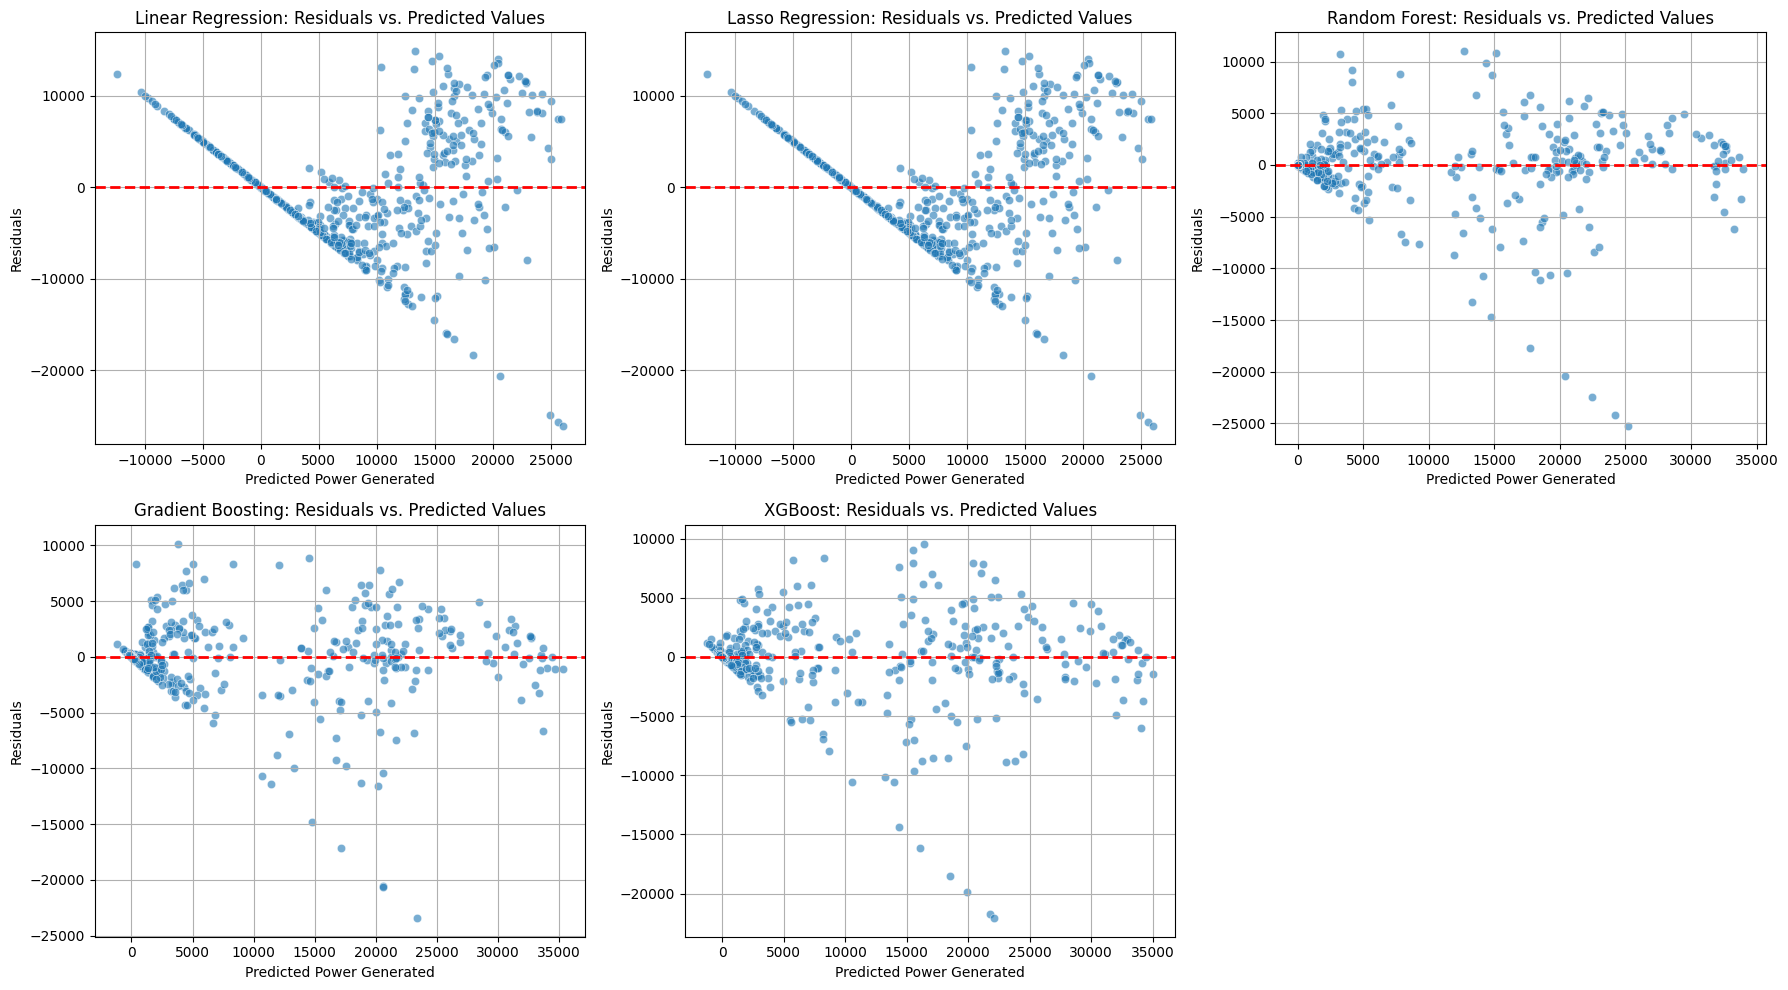

In [ ]:
plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, (model_name, predictions) in enumerate(models.items()):
    residuals = y_test - predictions
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=predictions, y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.title(f'{model_name}: Residuals vs. Predicted Values')
    plt.xlabel('Predicted Power Generated')
    plt.ylabel('Residuals')
    plt.grid(True)

plt.tight_layout()
plt.show()